## 4.3 极大极小设计

考虑式(3.5)中的最大熵准则:

$$\max\limits_{D}|\boldsymbol{R}|\tag{4.13}$$

设$\lambda_{1},\dots,\lambda_{n}$为矩阵$\boldsymbol{R}$的特征值.由几何均值恒小于算术均值可得:

$$\begin{align*}|\boldsymbol{R}|&=\prod_{i=1}^{n}\lambda_{i}\le\left(\frac{1}{n}\sum_{i=1}^{n}\lambda_{i}\right)^{n}\\&=\left(\frac{1}{n}\mathrm{tr}(\boldsymbol{R})\right)^{n}=1=|\boldsymbol{I}_{n}|\end{align*}$$

由此可知,最大熵准则旨在使相关矩阵尽可能接近单位矩阵,即尽可能减小$\boldsymbol{R}$的非对角元.据此可得到式(4.13)的替代准则:

$$\min\limits_{D}\|\boldsymbol{R}-\boldsymbol{I}_{n}\|_{\alpha}\tag{4.14}$$

式中$\|\cdot\|_{\alpha}$代表$L_{\alpha}$范数.相较于式(4.13),式(4.14)存在一项优势:式(4.14)的目标函数计算复杂度为$\mathcal{O}(n^{2})$,而式(4.13)的计算复杂度为$\mathcal{O}(n^{3})$.这一特性为优化计算带来了显著的运算优势.

考虑$L_{\infty}$范数.由于$\boldsymbol{R}$为正定矩阵(绝大多数常用相关函数均满足该条件),式(4.14)可改写为

$$\min_{D}\max_{i\ne j}|\boldsymbol{R}_{ij}|=\min_{D}\max_{i\ne j}\boldsymbol{R}_{ij}\tag{4.15}$$

假设采用式(4.3)中的各向同性高斯相关函数,则有

$$\begin{align*}\max_{i\ne j}\boldsymbol{R}_{ij}&=\max_{i\ne j}\exp\left(-\frac{\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|^{2}}{\theta^{2}}\right)\\&=\exp\left(-\min_{i\ne j}\frac{\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|^{2}}{\theta^{2}}\right)\\&=\exp\left(-4\frac{\psi^{2}(D)}{\theta^{2}}\right)\end{align*}$$

其中

$$\psi(D):=\frac{1}{2}\min_{i\ne j}\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|$$

称为设计$D$的分离距离(也叫填充半径)(Fasshauer,2007,第136页).能够最大化分离距离的设计称为极大极小距离设计,简称极大极小设计(Johnson等人,1990),其数学表达为

$$D^*=\argmax_{D}\min_{i\ne j}\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|\tag{4.16}$$

因此,极大极小设计旨在最大化全部设计点之间的最小两两距离.该类设计能够最小化$\boldsymbol{R}$的最大非对角相关系数,近似实现设计熵最大化.从几何角度来看,极大极小设计通过尽可能分散各采样点,力求完整填充整个试验区域$\mathcal{X}$.回顾上一节的加油站示例,极大极小设计可保证任意两座加油站不会距离过近,通过拉开站点间距弱化彼此间的客源竞争.由此可见,极大极小设计更侧重供给方视角,而极小极大设计则更侧重需求方视角.

极大极小设计并非唯一.图4.3展示了两组分离距离相等的设计,但显然第一种设计更优:该设计中仅有一组点对达到最小距离,而第二种设计存在两组此类点对.我们将间距等于$2\psi(D)$的点对数量定义为该设计的(极大极小)指标.我们期望该指标尽可能小,以避免过多采样点相互靠近.因此,可以将设计指标作为次级准则,对极大极小设计进一步优化.Johnson等人(1990)证明了如下结论.

>**定理4.2** 考虑相关函数$R(\boldsymbol{u}-\boldsymbol{v})=\rho^{k}(d(\boldsymbol{u},\boldsymbol{v}))$,其中$d$为距离度量,$\rho$为单调递减函数,且$k>0$.则当$k\to\infty$时,指标最小的极大极小设计渐近等价于最大熵设计.

>**图4.3** 两组包含7个采样点的设计,二者分离距离相等,但极大极小指标不同

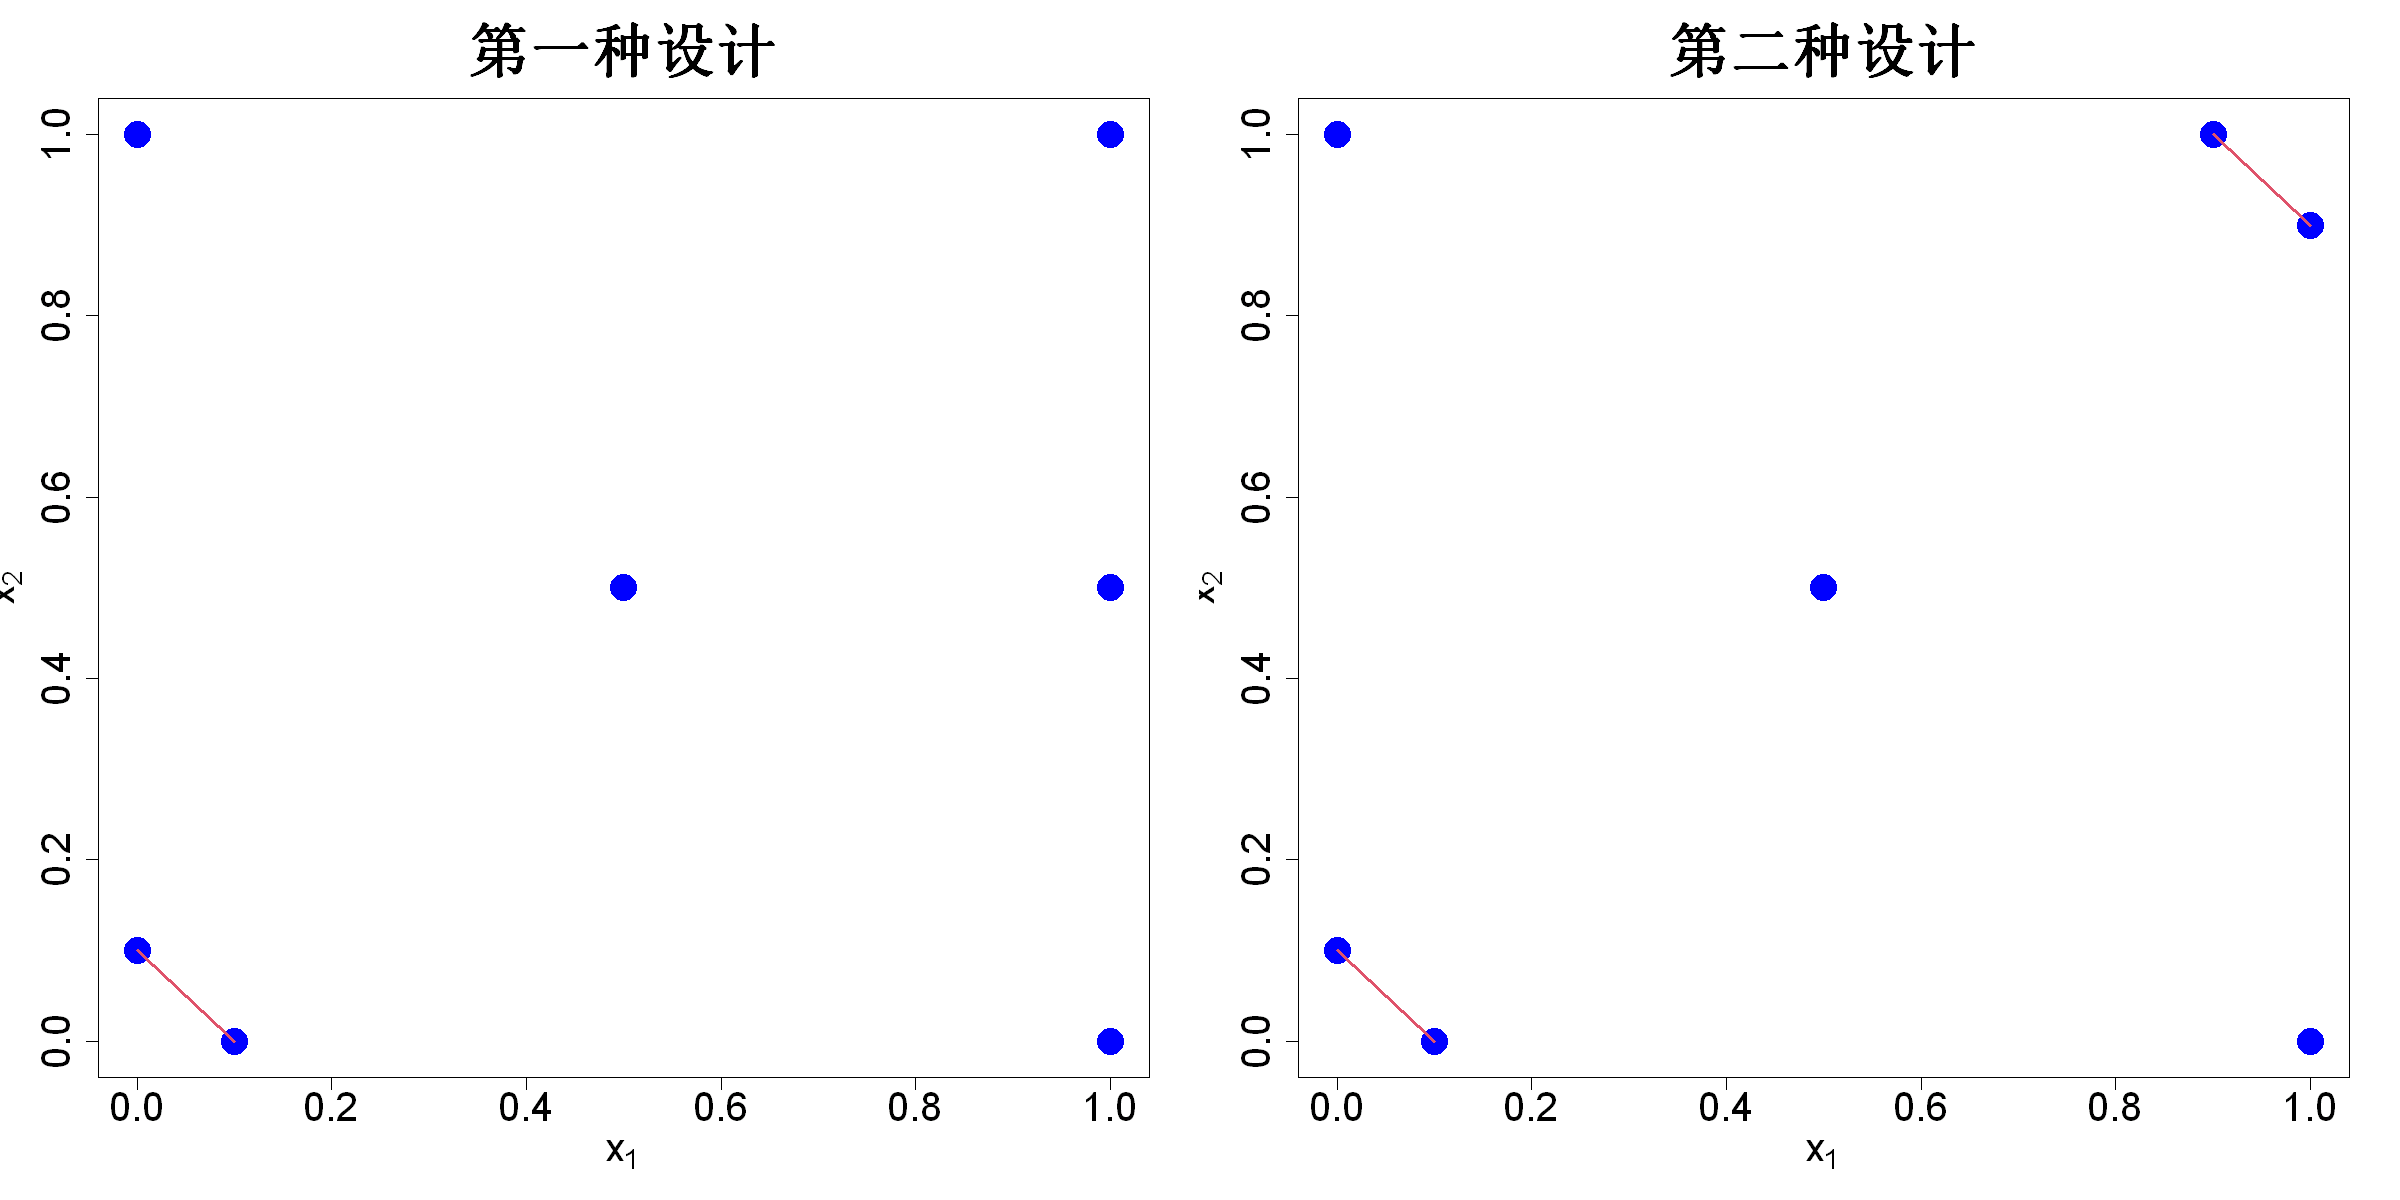

In [4]:
#图4.3

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=7
D1=matrix(c(0,.1,.1,0,0,1,1,1,1,.5,1,0,.5,.5),nrow=n,ncol=p,byrow=TRUE)
plot(D1,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",cex=3,main="第一种设计",cex.main=3)
segments(0,.1,.1,0,col=2,lwd=3)
D2=matrix(c(0,.1,.1,0,0,1,.9,1,1,.9,1,0,.5,.5),nrow=n,ncol=p,byrow=TRUE)
plot(D2,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",cex=3,main="第二种设计",cex.main=3)
segments(0,.1,.1,0,col=2,lwd=3)
segments(.9,1,1,.9,col=2,lwd=3)
par(mfrow=c(1,1))

下面考察表2.1中的有理二次(RQ)相关函数(拉斯穆森,威廉姆斯,2006,第86页),该函数也称作逆二次核或柯西核(法斯豪尔,麦考特,2015,第42页):

$$R(\boldsymbol{\Delta})=\frac{1}{\left(1+\frac{\|\boldsymbol{\Delta}\|^{2}}{\theta^{2}}\right)}\tag{4.17}$$

此时式(4.14)中的目标函数可写为

$$\begin{align*}\|\boldsymbol{R}-\boldsymbol{I}_{n}\|_{\alpha}^{\alpha}&=\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\left(1+\frac{\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|^{2}}{\theta^{2}}\right)^{\alpha}}\\&\le\theta^{2\alpha}\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|^{2\alpha}}\end{align*}$$

上式中的第二项为总倒数距离(TRD),该指标的优势是与参数$\theta$无关,可作为式(4.16)的替代准则.不难看出,当$\alpha$取值较大时,有

$$\begin{align*}\min_{D}\mathrm{TRD}(D)&=\min_{D}\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|^{2\alpha}}\tag{4.18}\\&\approx\min_{D}\frac{I}{\min_{i\ne j}\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|^{2\alpha}}\\&\equiv\max_{D}\frac{\min_{i\ne j}\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|}{I^{1/(2\alpha)}}\end{align*}$$

式中$I$为设计指标.因此,当$\alpha$足够大时,最小化$\mathrm{TRD}(D)$既能最大化最小点间距,又能最小化设计指标.从该角度而言,总倒数距离准则相比式(4.16)的极大极小准则效果更优(莫里斯,米切尔,1995).式(4.16)的优势在于其目标函数的计算复杂度为$\mathcal{O}(n\log n)$,而$\mathrm{TRD}(D)$的计算复杂度为$\mathcal{O}(n^{2})$.当$\alpha=1$时,$\mathrm{TRD}(D)$退化为奥兹与埃格莱斯(1977)提出的准则,该准则存在物理类比:最小化封闭盒内等质量质点间的万有引力总和.

与极小极大设计的情况类似,一维问题中求解极大极小设计十分容易.包含$n$个采样点的极大极小设计为

$$D=\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}\tag{4.19}$$

当维度$p\ge2$时该问题求解难度显著上升,仅$n=2p$这类特殊样本量取值除外.优化$\mathrm{TRD}(D)$更为简便,其梯度可推导为

$$\frac{\partial\mathrm{TRD}(D)}{\partial\boldsymbol{x}_k}=4\alpha\sum_{j\ne k}\frac{\boldsymbol{x}_j-\boldsymbol{x}_k}{\|\boldsymbol{x}_j-\boldsymbol{x}_k\|^{2\alpha+2}},\;k=1,\dots,n$$

可依托该梯度开展基于梯度的优化计算.由于$\mathrm{TRD}(D)$是多峰函数,该优化过程很容易收敛到局部最优解.因此需要设置多组随机初始点,以搜寻全局最优解.若需求解式(4.16)对应的极大极小设计,可采用无导数全局优化算法;当样本量$n$和维度$p$较大时,该算法运算速度较慢.R语言程序包`SFDesign`中实现了该算法(Wang与Joseph,2025c).

借助`SFDesign`得到的$n=7$,$p=2$情形下的极大极小设计如图4.4所示,该设计的分离距离为$\psi(D^{*})=0.26795$.以每个采样点为圆心,$\psi(D^{*})$为半径绘制圆形.极大极小设计的本质是最大化可围绕各设计点摆放,互不重叠的等半径球体半径,这使得该问题与数学领域经典的球体填充问题密切相关(康威,斯隆,2013).但绝大多数球体填充理论结论针对全空间$\mathbb{R}^p$内球体排布,而本文研究场景为超立方体区域.边界约束会导致极大极小设计与最优球体填充构型存在差异,已有研究尝试利用球体填充相关结论求解极大极小设计问题(何,2017b).这类问题属于高难度数学问题,仅部分特殊情形存在简单解.正如博罗达乔夫等人(2019,第11页)所言:"三维欧氏空间最优球体填充构型的证明悬而未决近四百年,但但凡堆叠过橙子的人其实早已知晓答案."网站`http://www.packomania.com/`收录了正方形与立方体区域下最优球体填充的相关结果,可查阅其中参考文献.

>**图4.4** 一组含7个采样点的极大极小设计

[1] 0.267948

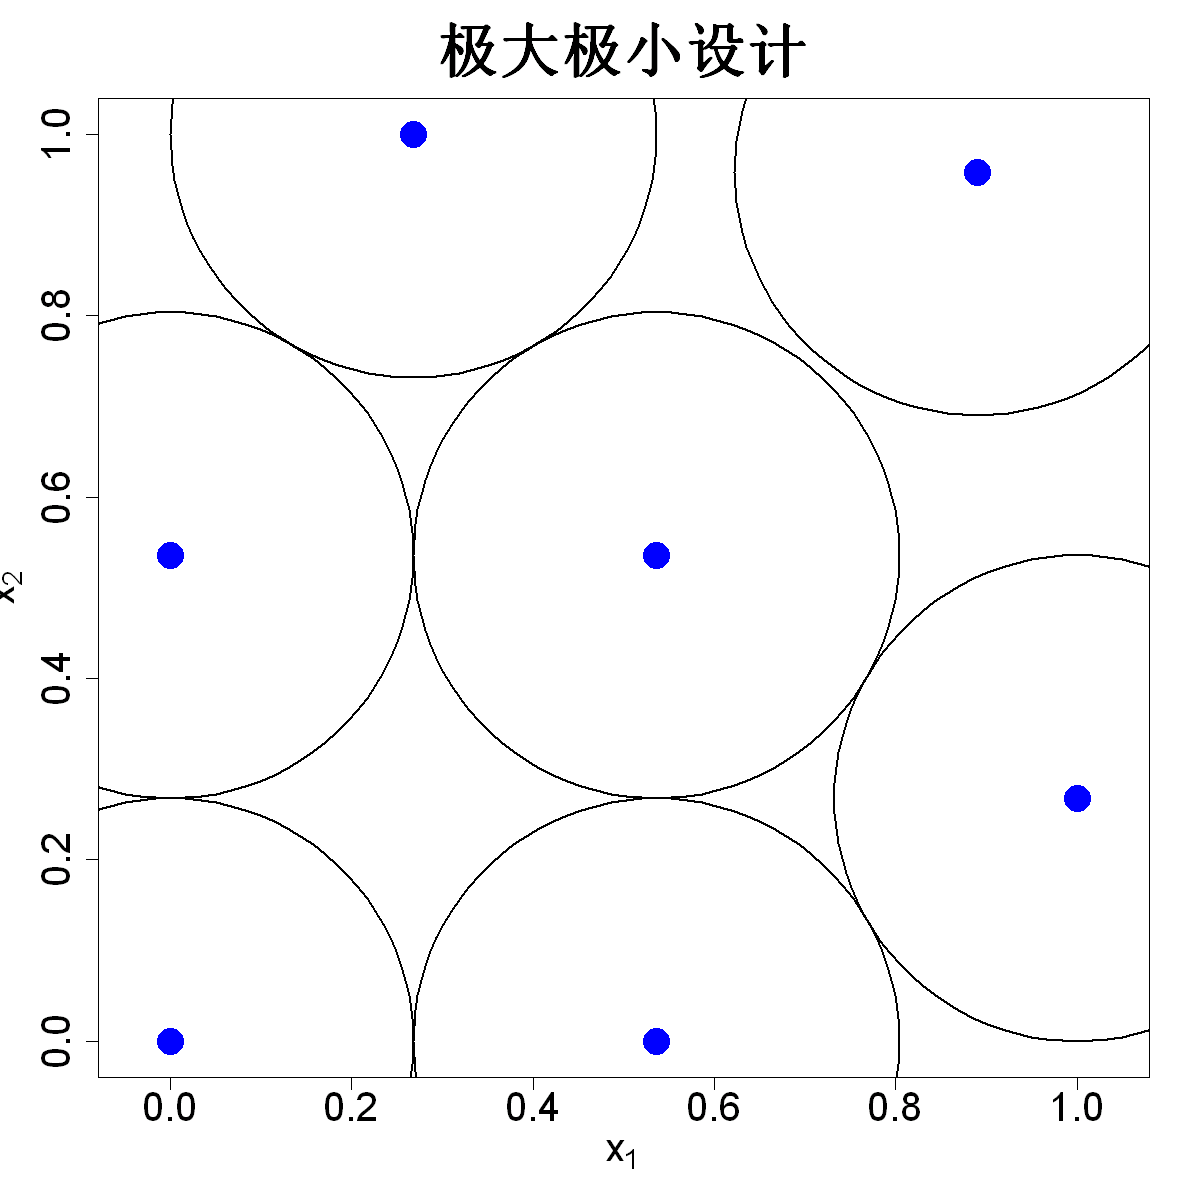

In [2]:
#图4.4

options(repr.plot.width=10,repr.plot.height=10)
p=2;n=7
set.seed(1)
library(SFDesign)
D=maximinLHD(n,p)$design
D=maximin.optim(D,sa=TRUE,find.best.ini=TRUE)$design
r=min(dist(D))/2;r
plot(D[,1],D[,2],xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",cex=3,cex.main=3,cex.lab=2,cex.axis=2,main="极大极小设计",asp=1)
library(plotrix)
for(i in 1:n)draw.circle(D[i,1],D[i,2],radius=r,lwd=2)

相较于聚类型设计与极小极大设计,极大极小设计的一大优势是便于序贯构造.例如,先选取一个初始点$\boldsymbol{x}_{1}$,再依据下式依次添加$\boldsymbol{x}_{2},\dots,\boldsymbol{x}_{n}$:

$$\boldsymbol{x}_{k+1}=\argmax_{\boldsymbol{x}\in\mathcal{X}}\min_{i=1:k}\|\boldsymbol{x}-\boldsymbol{x}_i\|,\;k=1,\dots,n-1\tag{4.20}$$

该方法最初由肯纳德,斯通(1969)针对物理试验提出.尚与阿普利(2021)给出了该算法的多种变体与改进方案.需要注意,上述方法仅用于初始设计的序贯生成;而第7章将要介绍的序贯设计方法,是在采集全部含响应值的数据后开展的.

图4.5左图展示了以中心点为起点,按照极大极小准则序贯新增六个采样点的结果.该操作可调用`SFDesign`程序包中的`maximin.augment`函数实现(王,约瑟夫,2025c).最终得到设计的分离距离$\psi(D)=0.25$,该数值小于图4.4中最优极大极小设计的分离距离.在此设计基础上继续序贯添加六个采样点,即可得到图4.5右图所示设计;该设计空间填充效果较好,但并非样本量为13的最优极大极小设计.

>**图4.5** 左图为由中心点出发序贯构造得到的极大极小设计;右图为基于该设计,按照极大极小准则再新增六个采样点(红色叉号)后的结果

In [3]:
#图4.5

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=7
set.seed(1)
D0=matrix(c(.5,.5),nrow=1,ncol=p)
library(SFDesign)
CAND=full.factorial(p=2,level=5)
D=maximin.augment(n=7,p=2,D.ini=D0,candidate=CAND)
min(dist(D))/2
plot(D,xlim=c(0,1),ylim=c(0,1),cex=4,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue")
plot(D,xlim=c(0,1),ylim=c(0,1),cex=4,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue")
D2=maximin.augment(n=13,p=2,D.ini=D,candidate=CAND)
min(dist(D2))/2
points(D2[8:13,],cex=4,lwd=5,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=4,col="red")
par(mfrow=c(1,1))

[1] 0.25

[1] 0.1767767